In [7]:
import os
import warnings

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

tf.keras.utils.set_random_seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


Problem Statement:

The aim of this project is to build a deep learning classification model that can recognize handwritten digits from 0 to 9. A neural network will be trained using the MNIST dataset. The model will learn patterns from handwritten digit images and predict the correct digit for previously unseen images.

In [8]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("MNIST dataset loaded successfully.")

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

MNIST dataset loaded successfully.
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


Dataset Description:

The MNIST dataset contains grayscale images of handwritten digits from 0 to 9. It consists of 60,000 training images and 10,000 testing images. Each image has a resolution of 28 × 28 pixels. Every image belongs to one of ten classes representing the digits 0 through 9.

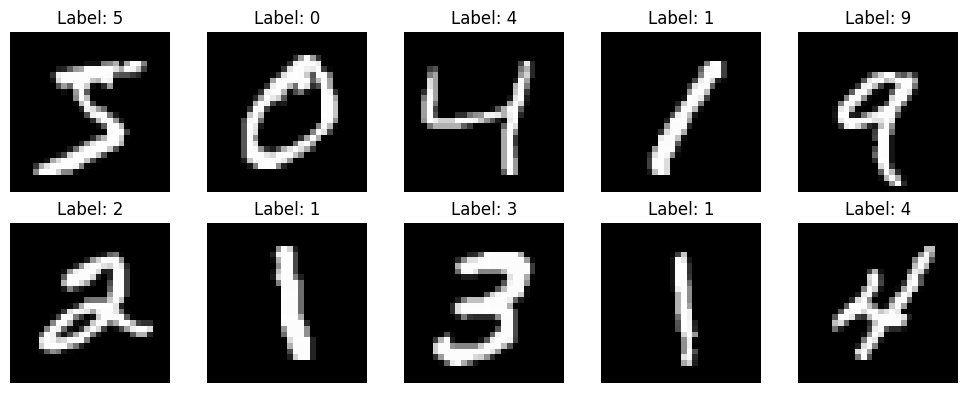

In [9]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title("Label: " + str(y_train[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Data preprocessing completed.")

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Data preprocessing completed.
Minimum pixel value: 0.0
Maximum pixel value: 1.0


Data Preprocessing:

The MNIST images originally contain pixel intensity values between 0 and 255. These values were normalized by dividing every pixel by 255, resulting in values between 0 and 1. Normalization helps the neural network train more efficiently and improves numerical stability. The dataset already provides separate training and testing sets, so an additional train-test split was not required.

In [11]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(28, 28)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Neural Network Architecture:

The neural network begins with a Flatten layer that converts each 28 × 28 image into 784 numerical input values. The first hidden layer contains 128 neurons with the ReLU activation function, followed by another hidden layer containing 64 neurons with ReLU activation. The output layer contains 10 neurons because the dataset contains ten possible digit classes. Softmax activation is used in the output layer to produce a probability for each digit from 0 to 9.

In [12]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.10,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9031 - loss: 0.3463 - val_accuracy: 0.9583 - val_loss: 0.1410
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9568 - loss: 0.1477 - val_accuracy: 0.9677 - val_loss: 0.1093
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9692 - loss: 0.1034 - val_accuracy: 0.9708 - val_loss: 0.0979
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9771 - loss: 0.0785 - val_accuracy: 0.9708 - val_loss: 0.0978
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9821 - loss: 0.0622 - val_accuracy: 0.9717 - val_loss: 0.0972
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9860 - loss: 0.0490 - val_accuracy: 0.9727 - val_loss: 0.0975
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9895 - loss: 0.0390 - val_accuracy: 0.9732 - val_loss: 0.0971
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9914 - loss: 0.0315 - val_accuracy: 0.

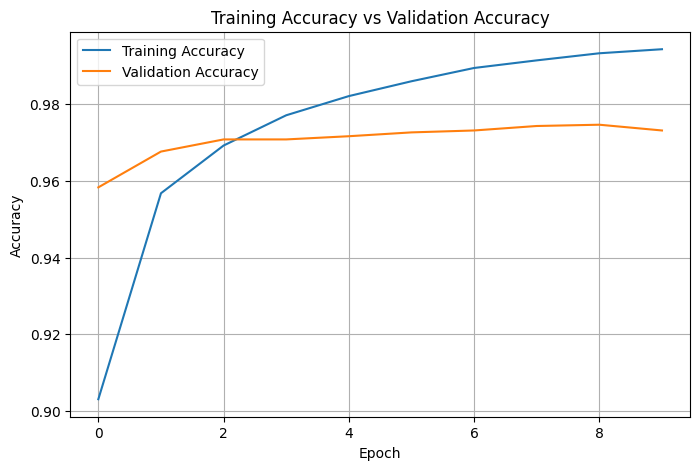

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training Accuracy vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

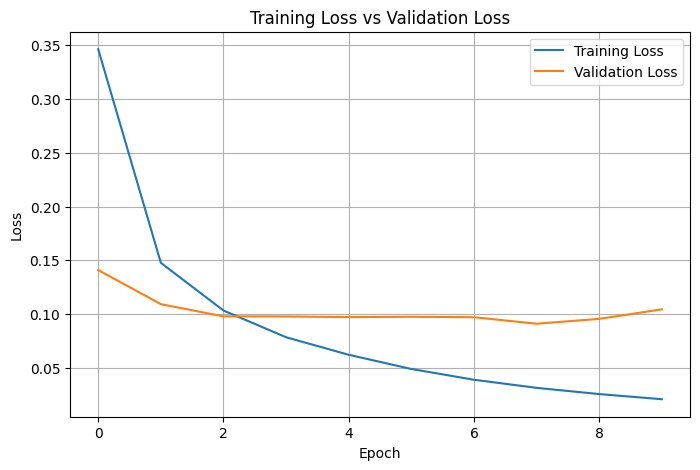

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training Loss vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

In [16]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

Test Loss: 0.1036
Test Accuracy: 97.07 %


In [17]:
prediction_probabilities = model.predict(
    X_test,
    verbose=0
)

predictions = np.argmax(
    prediction_probabilities,
    axis=1
)

print("Predictions generated successfully.")
print("Total predictions:", len(predictions))

Predictions generated successfully.
Total predictions: 10000


In [18]:
print(f"{'Sample':<10}{'Actual':<15}{'Predicted':<15}")
print("-" * 40)

for i in range(10):
    print(
        f"{i+1:<10}"
        f"{y_test[i]:<15}"
        f"{predictions[i]:<15}"
    )

Sample    Actual         Predicted      
----------------------------------------
1         7              7              
2         2              2              
3         1              1              
4         0              0              
5         4              4              
6         1              1              
7         4              4              
8         9              9              
9         5              5              
10        9              9              


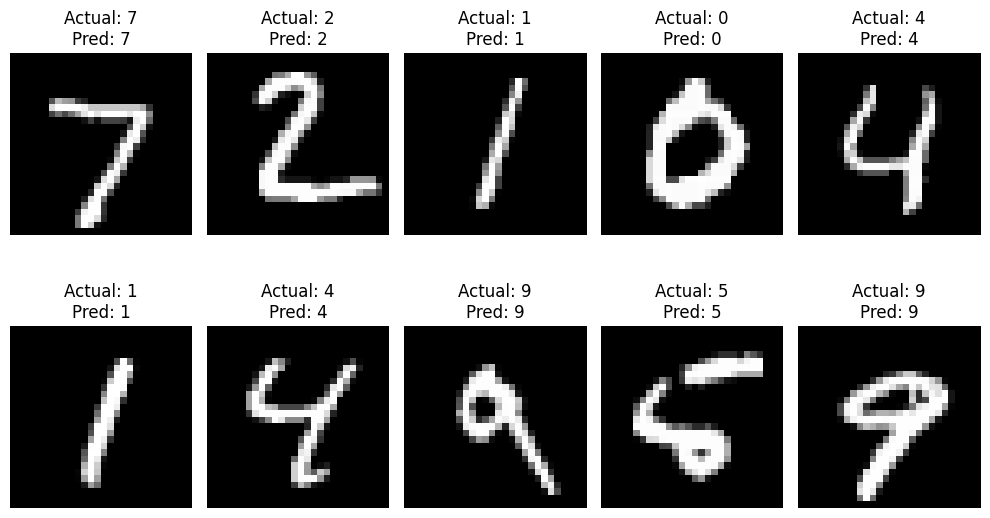

In [21]:
plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_test[i],
        cmap="gray"
    )

    plt.title(
        f"Actual: {y_test[i]}\n"
        f"Pred: {predictions[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

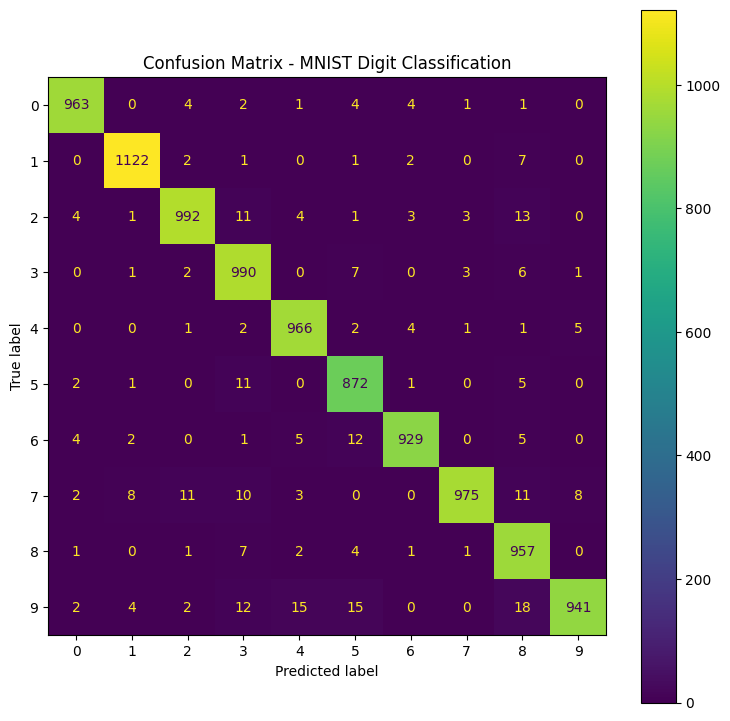

In [22]:
cm = confusion_matrix(
    y_test,
    predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

fig, ax = plt.subplots(figsize=(9, 9))

display.plot(
    ax=ax,
    values_format="d"
)

plt.title("Confusion Matrix - MNIST Digit Classification")
plt.show()

In [23]:
correct_predictions = np.sum(
    y_test == predictions
)

incorrect_predictions = np.sum(
    y_test != predictions
)

print("Total test images       :", len(y_test))
print("Correct predictions     :", correct_predictions)
print("Incorrect predictions   :", incorrect_predictions)

print(
    "Test accuracy           :",
    round(test_accuracy * 100, 2),
    "%"
)

Total test images       : 10000
Correct predictions     : 9707
Incorrect predictions   : 293
Test accuracy           : 97.07 %


Total incorrect predictions: 293


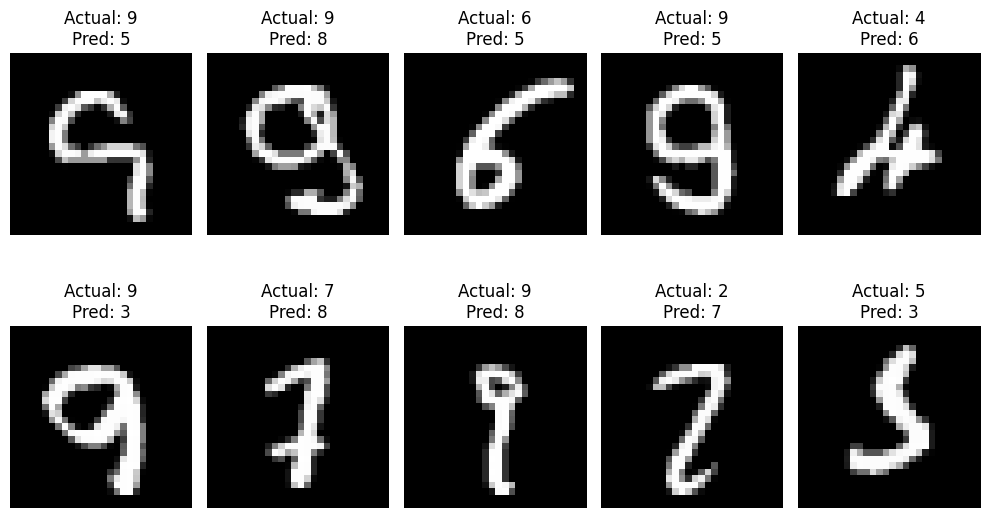

In [24]:
incorrect_indices = np.where(
    y_test != predictions
)[0]

print(
    "Total incorrect predictions:",
    len(incorrect_indices)
)

plt.figure(figsize=(10, 6))

for i, index in enumerate(incorrect_indices[:10]):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_test[index],
        cmap="gray"
    )

    plt.title(
        f"Actual: {y_test[index]}\n"
        f"Pred: {predictions[index]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

Final Conclusion
The neural network successfully learned to classify handwritten digits from the MNIST dataset. Training and validation accuracy increased during the training process, while the corresponding loss values generally decreased. The model achieved high classification accuracy on the unseen test dataset. The confusion matrix and prediction examples demonstrate that most handwritten digits were correctly identified. Some errors can occur when different handwritten digits have similar shapes or unclear handwriting. Overall, the project demonstrates how an artificial neural network can learn patterns from image pixel values and use those patterns to classify previously unseen images.

The objective of this project was to develop a deep learning classification model capable of recognizing handwritten digits from 0 to 9. Handwritten digit recognition is an important image-classification problem and demonstrates how neural networks can automatically learn patterns from numerical image data.
The MNIST dataset was used for this project. It contains 70,000 grayscale handwritten digit images, including 60,000 training images and 10,000 testing images. Each image has a resolution of 28 × 28 pixels. Before training, the pixel values were normalized from the original range of 0–255 to a range of 0–1. Normalization allows the neural network to train more efficiently.
The neural network consisted of a Flatten layer, followed by two fully connected hidden layers containing 128 and 64 neurons. ReLU activation was used in both hidden layers. The output layer contained 10 neurons representing digits 0 through 9 and used the Softmax activation function. The model was compiled using the Adam optimizer and sparse categorical crossentropy loss.
The model was trained for 10 epochs while monitoring both training and validation performance. During training, accuracy generally increased while loss decreased, demonstrating that the neural network was learning useful digit patterns. Evaluation on the independent test dataset showed high classification performance. The prediction examples and confusion matrix demonstrated that most handwritten digits were correctly classified.
A limitation of the model is that similar or poorly written digits can occasionally be misclassified. The model also uses a basic fully connected architecture and does not explicitly capture spatial image features. Future improvements could include using a Convolutional Neural Network, additional training, hyperparameter tuning and image augmentation to improve classification performance further.